<a href="https://colab.research.google.com/github/luiscoello/Data-Sciecne/blob/main/proyect3_timeseriesvisualizer_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Import data (Make sure to parse dates. Consider setting index column to 'date'.)
df = pd.read_csv('/fcc-forum-pageviews.csv', parse_dates=['date'], index_col='date')

# Clean data
df = df[(df['value'] >= df['value'].quantile(0.025)) & (df['value'] <= df['value'].quantile(0.975))]

def draw_line_plot():
    # Draw line plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df.index, df['value'], color='red')
    ax.set_title('Daily freeCodeCamp Forum Page Views 2016-2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')


    # Save image and return fig (don't change this part)
    fig.savefig('line_plot.png')
    return fig

def draw_bar_plot():
    # Copy and modify data for monthly bar plot
    df_bar = df.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.month
    df_bar['month_name'] = df_bar.index.month_name()
    df_bar['month_name'] = pd.Categorical(df_bar['month_name'], categories=[
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ], ordered=True)
    df_grouped = df_bar.groupby(['year', 'month_name'])['value'].mean().unstack()

    # Draw bar plot

    fig = df_grouped.plot(kind='bar', figsize=(15, 10)).figure
    plt.xlabel('Years')
    plt.ylabel('Average Page Views')
    plt.legend(title='Months')
    plt.tight_layout()



    # Save image and return fig (don't change this part)
    fig.savefig('bar_plot.png')
    return fig

def draw_box_plot():
    # Prepare data for box plots (this part is done!)
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = [d.year for d in df_box.date]
    df_box['month'] = [d.strftime('%b') for d in df_box.date]
    df_box['month_num'] = df_box['date'].dt.month
    # Draw box plots (using Seaborn)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
    sns.boxplot(x='year', y='value', data=df_box, ax=axes[0])
    axes[0].set_title('Year-wise Box Plot (Trend)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Page Views')

    #Right Box Plot
    sns.boxplot(x='month', y='value', data=df_box, ax=axes[1])
    axes[1].set_title('Month-wise Box Plot (Seasonality)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Page Views')
    plt.tight_layout()


    # Save image and return fig (don't change this part)
    fig.savefig('box_plot.png')
    return fig

In [ ]:
draw_box_plot

<function __main__.draw_box_plot()>

/tmp/ipython-input-25-4173108901.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df_bar.groupby(['year', 'month_name'])['value'].mean().unstack()


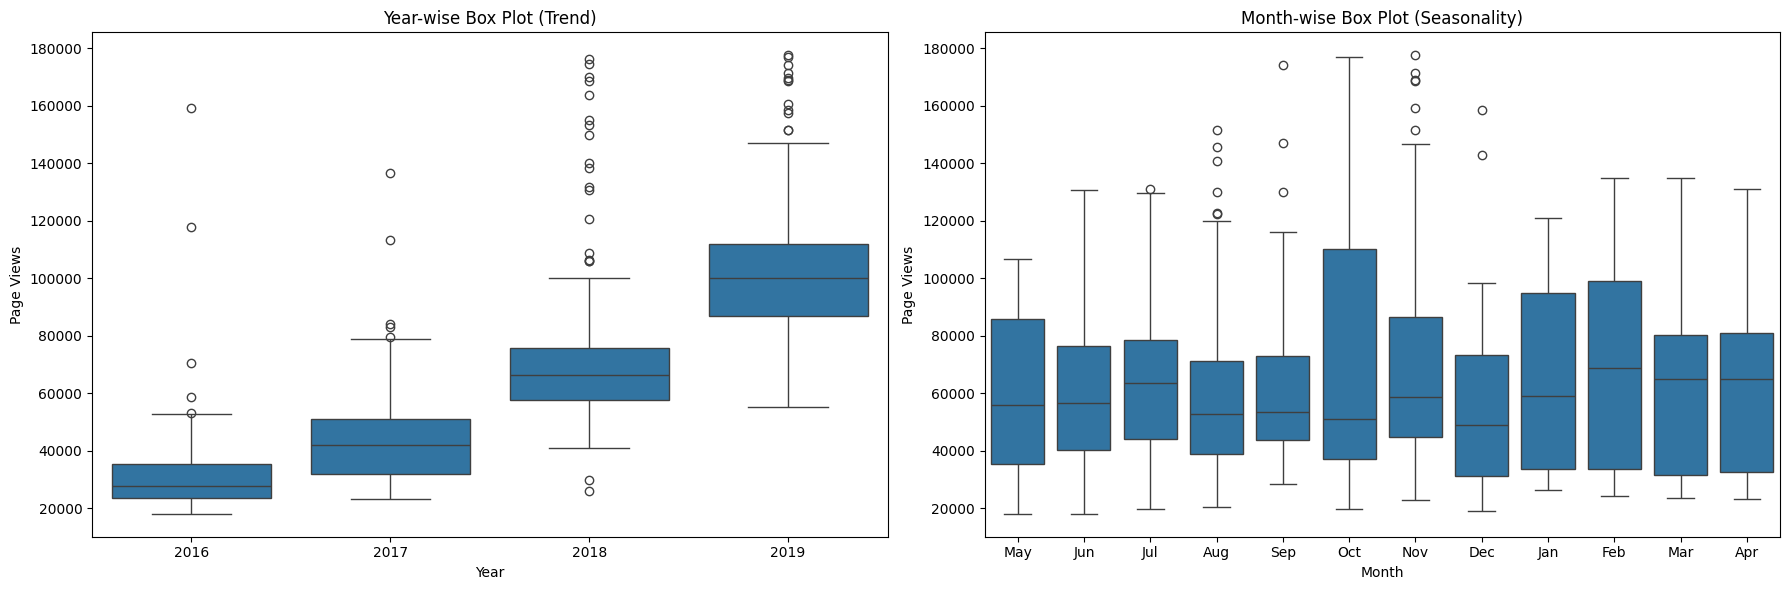

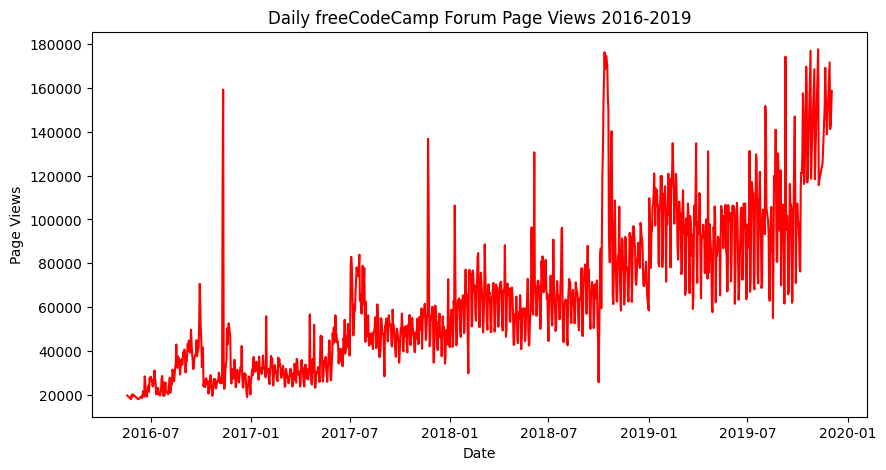

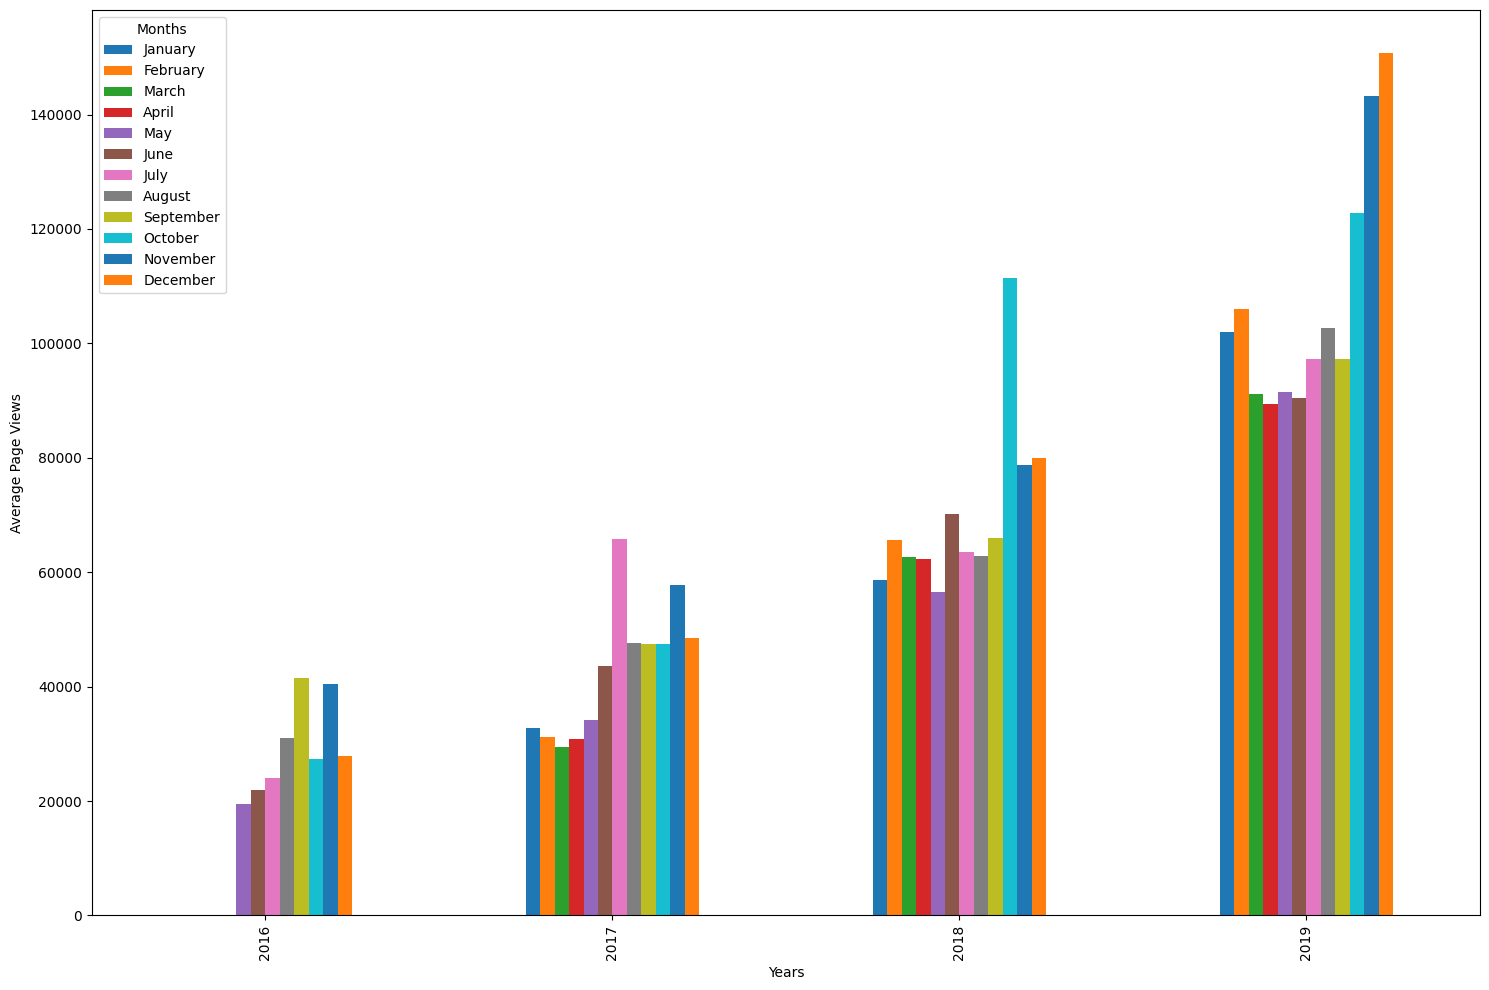

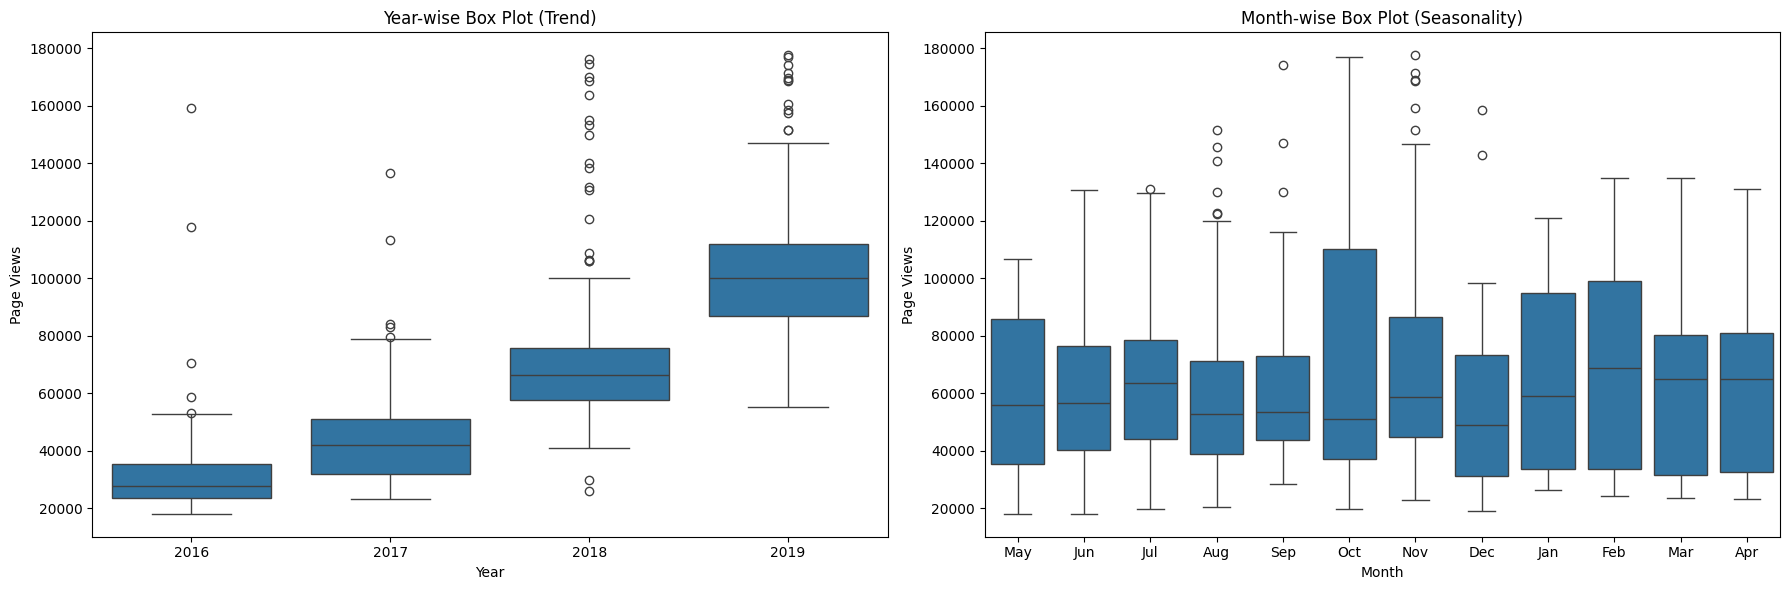

In [ ]:
draw_line_plot()
draw_bar_plot()
draw_box_plot()